In [46]:
library(Seurat)
library(scop)
library(Signac)
library(ggplot2)
set.seed(4180)
library(patchwork)
setwd("/")
#########color
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

In [2]:
sc_list <- readRDS('data/sc_list_bfqc.Rds')

In [3]:
library(dplyr)
#########
sc_list <- lapply(sc_list, function(x) {
 x[['ATAC']] <- NULL
 return(x)
})
sample_name <- c(
 "NP1", "NP2", "NP3",
 "EP1", "EP2", "EP3",
 "MP1", "MP2", "MP3",
 "LP1", "LP2", "LP3",
 "PP1", "PP2", "PP3"
)
gc()
mHeart <- merge(sc_list[[1]], y = sc_list[-1], add.cell.ids = sample_name)
mHeart <- mHeart %>%
 NormalizeData(assay = 'RNA') %>%
 FindVariableFeatures(assay = 'RNA') %>%
 ScaleData(vars.to.regress = c("percent.mt", "percent.rb", "percent.hsp"),assay = 'RNA') %>%
 RunPCA(assay = 'RNA')
gc()
#####
mHeart <- IntegrateLayers(
 object = mHeart, method = HarmonyIntegration,
 orig.reduction = "pca", new.reduction = "harmony",
 verbose = FALSE
)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7362385,393.2,13861375,740.3,9032757,482.5
Vcells,362371188,2764.7,3165748094,24152.8,3299288900,25171.6


Normalizing layer: counts.NP1

Normalizing layer: counts.NP2

Normalizing layer: counts.NP3

Normalizing layer: counts.EP1

Normalizing layer: counts.EP2

Normalizing layer: counts.EP3

Normalizing layer: counts.MP1

Normalizing layer: counts.MP2

Normalizing layer: counts.MP3

Normalizing layer: counts.LP1

Normalizing layer: counts.LP2

Normalizing layer: counts.LP3

Normalizing layer: counts.PP1

Normalizing layer: counts.PP2

Normalizing layer: counts.PP3

Finding variable features for layer counts.NP1

Finding variable features for layer counts.NP2

Finding variable features for layer counts.NP3

Finding variable features for layer counts.EP1

Finding variable features for layer counts.EP2

Finding variable features for layer counts.EP3

Finding variable features for layer counts.MP1

Finding variable features for layer counts.MP2

Finding variable features for layer counts.MP3

Finding variable features for layer counts.LP1

Finding variable features for layer counts.LP2

Finding

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7598148,405.8,13861375,740.3,13861375,740.3
Vcells,1418013529,10818.6,3165748094,24152.8,3299288900,25171.6


The `features` argument is ignored by `HarmonyIntegration`.
This message is displayed once per session.
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 8684650)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 8684650)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 8684650)”


In [4]:
mHeart[["RNA"]] <- JoinLayers(mHeart[["RNA"]])
mHeart <- RunUMAP(mHeart, reduction = 'harmony', dims = 1:20, assay = "RNA")

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
00:25:53 UMAP embedding parameters a = 0.9922 b = 1.112

00:25:53 Read 173693 rows and found 20 numeric columns

00:25:53 Using Annoy for neighbor search, n_neighbors = 30

00:25:53 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

00:26:08 Writing NN index file to temp file /tmp/RtmpScvrgK/file5dc2e77b3606c

00:26:08 Searching Annoy index using 1 thread, search_k = 3000

00:27:11 Annoy recall = 100%

00:27:13 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

In [5]:
obj <- readRDS('data/mHeart.Rds')
remain.cells <- colnames(obj)
mHeart$QC <- ifelse(colnames(mHeart) %in% remain.cells, "Remaining", "Removed")

✔ Created directory: plot/figureS1/.



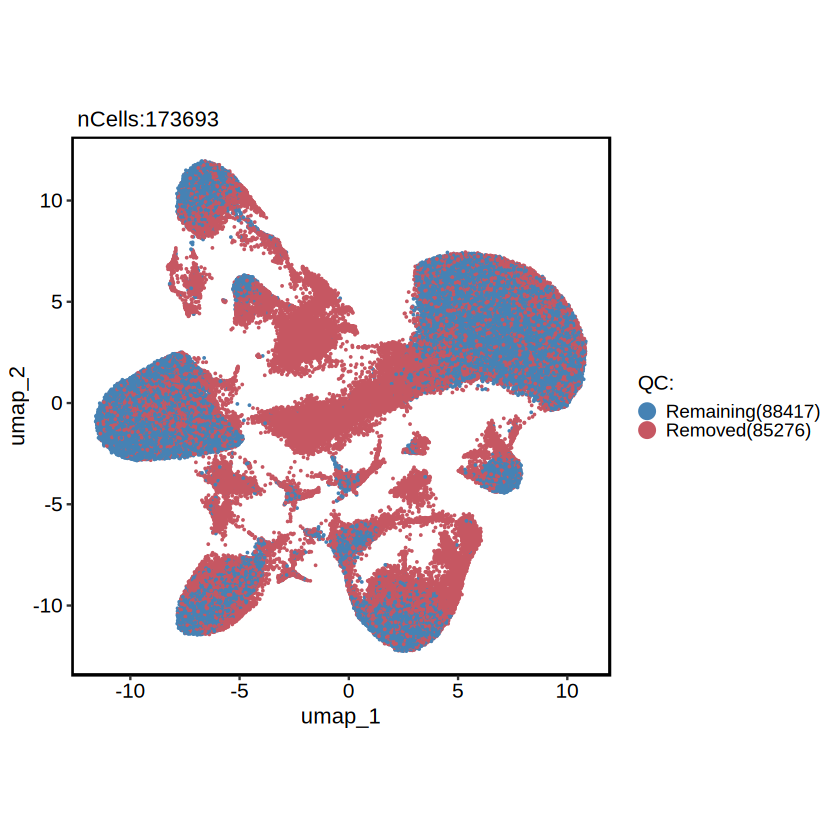

In [6]:
#S1f
p <- CellDimPlot(
 srt = mHeart, group.by = "QC",
 legend.position = "right", label_repel = T,
 label_point_size = 0.1, reduction = "umap",
 label = F, label_insitu = T,
 theme_use = "theme_scop",
 palcolor = c("#4682B4","#C65762"), raster = F,
 label.fg = "black", label.bg = "grey95",
 label.bg.r = 0
)
ggsave(
 plot = p, filename = "S1f.pdf", path = "plot/figureS1/",
 create.dir = TRUE, width = 5, height = 4
)
p

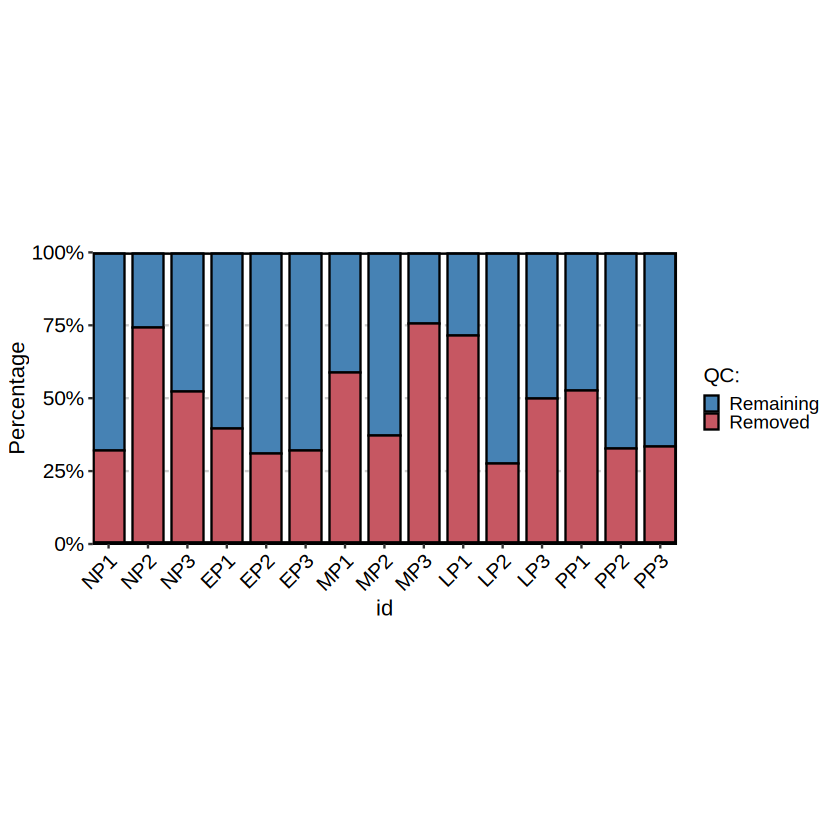

In [7]:
#S1g
p <- CellStatPlot(
 mHeart,
 stat.by = c(
 "QC"
 ),group.by = "id",
 plot_type = "bar",
 palcolor = c("#4682B4","#C65762")
) + ggplot2::theme(aspect.ratio = 1 / 2)
ggsave(
 plot = p, filename = "S1g.pdf", path = "plot/figureS1/",
 create.dir = TRUE, width = 8, height = 3
)
p

In [8]:
mHeart$log10GenesPerUMI <- log10(mHeart$nFeature_RNA)/log10(mHeart$nCount_RNA)
mHeart$log10nCount_RNA <- log10(mHeart$nCount_RNA)
mHeart$log10nFeature_RNA <- log10(mHeart$nFeature_RNA)

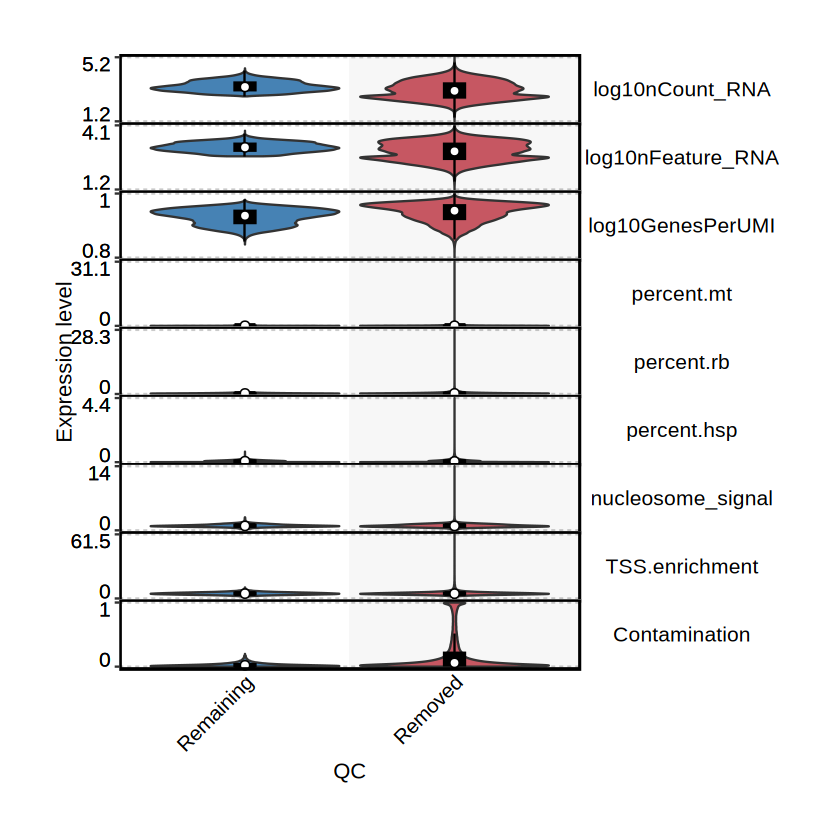

In [9]:
#S1h
p <- FeatureStatPlot(
 mHeart,
 group.by = "QC",
 stat.by = c("log10nCount_RNA", 
 "log10nFeature_RNA", 
 "log10GenesPerUMI", 
 "percent.mt",
 "percent.rb",
 "percent.hsp",
 "nucleosome_signal",
 "TSS.enrichment",
 "Contamination"),
 add_box = TRUE,stack = T,palcolor = c("#4682B4", "#C65762")
)
ggsave(
 plot = p, filename = "S1h.pdf", path = "plot/figureS1/",
 create.dir = TRUE, width = 4, height = 8
)
p

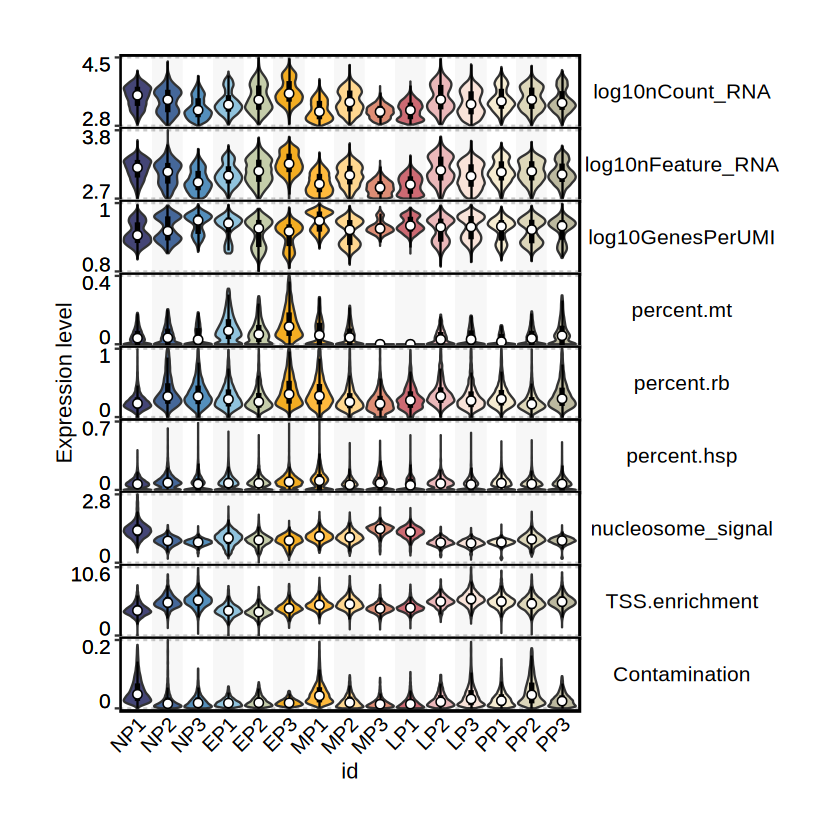

In [10]:
#S1h
p <- FeatureStatPlot(
 obj,
 group.by = "id",
 stat.by = c("log10nCount_RNA", 
 "log10nFeature_RNA", 
 "log10GenesPerUMI", 
 "percent.mt",
 "percent.rb",
 "percent.hsp",
 "nucleosome_signal",
 "TSS.enrichment",
 "Contamination"),
 add_box = TRUE,stack = T,palcolor =pal(15)
)
ggsave(
 plot = p, filename = "S1i.pdf", path = "plot/figureS1/",
 create.dir = TRUE, width = 8, height = 8
)
p

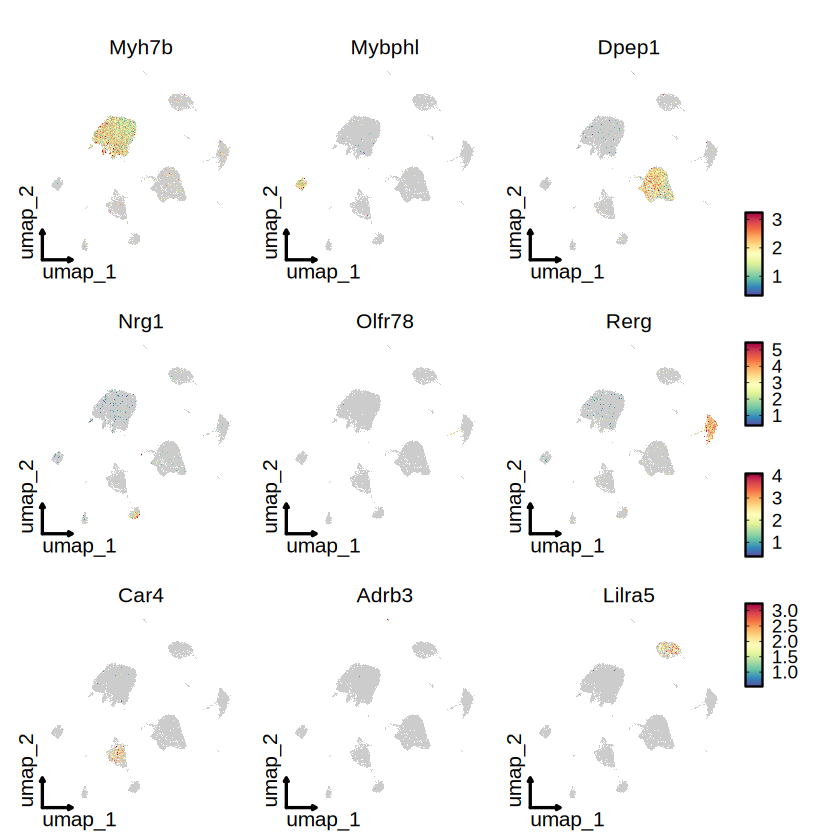

In [11]:
#S1j
p <- FeatureDimPlot(obj,features = c("Myh7b","Mybphl","Dpep1","Nrg1",
 "Olfr78","Rerg","Car4","Adrb3",
 "Lilra5"),theme_use = "theme_blank",raster = T,ncol=3
 )+ patchwork::plot_layout(
 guides = "collect"
)
ggsave(
 plot = p, filename = "S1j.pdf", path = "plot/figureS1/",
 create.dir = TRUE, width = 10, height = 9
)
p

In [2]:
mHeart <- readRDS("data/mHeart.Rds")
mHeart[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[["ATAC"]]

In [3]:
mHeart[["ATAC"]]

ChromatinAssay data with 192633 features for 88417 cells
Variable features: 192633 
Genome: 
Annotation present: TRUE 
Motifs present: TRUE 
Fragment files: 15 

In [4]:
#figS1k
library(RColorBrewer)
library(ggplot2)
DefaultAssay(mHeart) <- "ATAC"
cols <- brewer.pal(9,'Set1')
pal <- colorRampPalette(cols)
markergenes <- c('Myh7b','Mybphl','Dpep1','Car4','Nrg1','Olfr78','Rerg','Adrb3','Lilra5')
for (i in markergenes){
p1 <- CoveragePlot(
 assay = 'ATAC',
 object = mHeart,
 region = i,
 group.by='celltype',
 peaks = FALSE,
 annotation = FALSE
) + scale_fill_manual(values = pal(14))
p2 <- AnnotationPlot(
 object = mHeart,
 region = i
)
p <-CombineTracks(
 plotlist = list(p1, p2),
 heights = c(10, 1),
 widths = c(10,10)
)
ggsave(paste('S1k_',i,'.pdf',sep = '')
 ,p,path = "plot/figureS1/",width=5,height=5)
}

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>.”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>.”
Warning message:
“Removed 71 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scal

In [6]:
mHeart[["activity"]] <- readRDS("data/activity.Rds")[["activity"]]

In [28]:
#figS1l
library(Seurat)
library(dplyr)
library(tidyr)
library(ComplexHeatmap)
library(circlize)
#
rnamarker <- FindAllMarkers(mHeart,min.pct = 0.1,logfc.threshold = 0.5,only.pos = T,assay = 'RNA')
rna_genes <-rnamarker %>%
 group_by(cluster) %>%
 slice_max(order_by = avg_log2FC, n = 200)
acmarker <- FindAllMarkers(mHeart,min.pct = 0.1,logfc.threshold = 0.5,only.pos = T,assay = 'activity')
acmarker <-acmarker %>%
 group_by(cluster) %>%
 slice_max(order_by = avg_log2FC, n = 200)

Calculating cluster vCM



Calculating cluster aCM

Calculating cluster FB

Calculating cluster EC

Calculating cluster EndoCC

Calculating cluster LEC

Calculating cluster SMC

Calculating cluster Pericyte

Calculating cluster Adipocyte

Calculating cluster Neuronal

Calculating cluster T

Calculating cluster B

Calculating cluster Macrophage

Calculating cluster DC

Calculating cluster vCM

Calculating cluster aCM

Calculating cluster FB

Calculating cluster EC

Calculating cluster EndoCC

Calculating cluster LEC

Calculating cluster SMC

Calculating cluster Pericyte

Calculating cluster Adipocyte

Calculating cluster Neuronal

Calculating cluster T

Calculating cluster B

Calculating cluster Macrophage

Calculating cluster DC



In [34]:
ac_top <-acmarker %>%
 group_by(cluster) %>%
 slice_max(order_by = avg_log2FC, n = 1)

In [36]:
ac_top

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
0.000000e+00,3.787806,0.434,0.034,0.000000e+00,vCM,Lrtm1
0.000000e+00,4.582871,0.259,0.014,0.000000e+00,aCM,Sln
0.000000e+00,3.755533,0.194,0.017,0.000000e+00,FB,Lum
0.000000e+00,4.317882,0.139,0.011,0.000000e+00,EC,Ctla2a
0.000000e+00,3.944165,0.113,0.010,0.000000e+00,EndoCC,Krtap5-5
2.669670e-134,3.897989,0.208,0.014,5.822015e-130,LEC,Ang2
4.342628e-21,3.802076,0.101,0.014,9.470404e-17,SMC,Rergl
0.000000e+00,4.484675,0.357,0.030,0.000000e+00,Pericyte,Higd1b
0.000000e+00,4.990825,0.385,0.022,0.000000e+00,Adipocyte,Cyp2e1


In [40]:
#gene
marker <- readxl::read_excel("database/Marker.xlsx")
markers.to.plot <- unique(marker$gene)
RNAplot <- GroupHeatmap(
 srt = subset(mHeart), features = rna_genes$gene, group.by = "celltype",show_row_names =F,cell_annotation_palette = c("jama"),
 cluster_rows =FALSE, cluster_columns = FALSE,assay = 'RNA',layer= 'data',nlabel = 0,anno_terms = F,species = "Mus_musculus",
 show_column_names = T,column_names_rot = 45,column_title = '',heatmap_palcolor = c('white','white','brown'),
 group_palcolor=pal(13),features_label=markers.to.plot ,cell_annotation="group"
)
ggsave("S1l_gene_top.pdf",RNAplot$plot,path = "plot/figureS1/",width=7,height=7)
ACTplot <- GroupHeatmap(
 srt = subset(mHeart), features = acmarker$gene, group.by = "celltype",show_row_names =F,cell_annotation_palette = c("jama"),
 cluster_rows =FALSE, cluster_columns = FALSE,assay = 'activity',layer= 'data',nlabel = 0,anno_terms = F,species = "Mus_musculus",
 show_column_names = T,column_names_rot = 45,column_title = '',heatmap_palcolor = c('white','white','#BF5C00'),
 group_palcolor=pal(13),,features_label= c(markers.to.plot,"Iglc2","Rergl","Krt19","Cyp2e1","Fasl") ,cell_annotation="group"
)
ggsave("S1l_activity_bottom.pdf",ACTplot$plot,path = "plot/figureS1/",width=7,height=7)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.8 GiB”
! [2026-05-08 19:32:51] Myl2was not found in the features

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.8 GiB”
! [2026-05-08 19:33:34] Ryr2,Col1a1,Gsn,Actn1,Scd1,Lipe,Plxna4,Grip1,Adgre1,Alcamwas not found in the features

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



In [49]:
#figS1m
p1<-CellDimPlot(
 srt = mHeart,group.by = 'celltype',legend.position = 'none',label_repel = T,label_point_size = 0.1,
 reduction = "umap", label = F,label_insitu = T,theme_use = 'theme_blank',palcolor =pal(14),raster = T,
 label.fg = 'black',label.bg = 'grey95',label.bg.r = 0,split.by="id",ncol=3,pt.size=2
)
ggsave("S1m.pdf",p1,path = "plot/figureS1/",width=7,height=12)

In [50]:
#figS1n
p1<-CellStatPlot(mHeart, stat.by = "celltype",plot_type = "pie",palcolor = pal(13),xlab = '',ylab = '')
ggsave("S1n.pdf",p1,path = "plot/figureS1/",width=5,height=4)